# Entrenamiento YOLOv10 - Dataset Combinado

Notebook para entrenar el modelo con imágenes de producto individual + multi-producto.

## Prerrequisitos

1. Haber ejecutado `train.ipynb` (POC con productos individuales)
2. Haber anotado las imágenes multi-producto en Roboflow
3. Descargar el nuevo dataset combinado de Google Drive

## Configuración

In [1]:
import os
os.environ.pop('MPLBACKEND', None)

import matplotlib
matplotlib.use('Agg')

from pathlib import Path
from datetime import datetime

from ultralytics import YOLO

In [ ]:
# Hiperparámetros
MODEL_NAME = "yolov10n.pt"  # Opciones: yolov10n/s/m/b/l/x
BASE_MODELS_DIR = Path("../models/base").resolve()
DATA_YAML = Path("../data/poc_multiproduct/data.yaml").resolve()
EPOCHS = 100
IMGSZ = 640
BATCH = 16
PROJECT = str(Path("../runs/train").resolve())
NAME = "multiproduct_" + datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Modelo base: {BASE_MODELS_DIR / MODEL_NAME}")
print(f"Dataset: {DATA_YAML}")
print(f"Runs: {PROJECT}")
print(f"Nombre: {NAME}")

## Verificar dataset combinado

In [3]:
import yaml

if not DATA_YAML.exists():
    print("⚠️  Dataset combinado no encontrado!")
    print("")
    print("Pasos para crear el dataset combinado:")
    print("1. Subir data/jpg/varios_productos/ a Roboflow")
    print("2. Anotar bounding boxes en cada imagen")
    print("3. En Roboflow: Add images to existing project (POC)")
    print("4. Generate new version")
    print("5. Export como 'YOLO v5 PyTorch'")
    print("6. Descargar y extraer en data/poc_multiproduct/")
    print("")
    print("Estructura esperada:")
    print("  data/poc_multiproduct/")
    print("  ├── data.yaml")
    print("  ├── train/images/  (~140+ imágenes)")
    print("  ├── train/labels/")
    print("  ├── val/images/")
    print("  └── val/labels/")
else:
    # Leer y actualizar path absoluto
    with open(DATA_YAML) as f:
        data_config = yaml.safe_load(f)
    
    data_config['path'] = str(DATA_YAML.parent)
    
    with open(DATA_YAML, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)
    
    print("✓ Dataset combinado encontrado")
    print(DATA_YAML.read_text())

✓ Dataset combinado encontrado
train: train/images
val: val/images
test: test/images
names:
  0: aceite_1l
  1: aceite_4l
  2: dulce_de_leche
  3: fideos
  4: leche_descremada
  5: leche_entera
  6: miel
  7: polenta
  8: tomate
  9: yerba_kalena
path: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_multiproduct



In [4]:
# Contar imágenes
if DATA_YAML.exists():
    train_images = list((DATA_YAML.parent / "train" / "images").glob("*"))
    val_images = list((DATA_YAML.parent / "val" / "images").glob("*"))
    
    print(f"Imágenes de entrenamiento: {len(train_images)}")
    print(f"Imágenes de validación: {len(val_images)}")
    print(f"Total: {len(train_images) + len(val_images)}")

Imágenes de entrenamiento: 132
Imágenes de validación: 19
Total: 151


## Entrenar modelo

In [ ]:
# Load model from models/base/
model_path = BASE_MODELS_DIR / MODEL_NAME
if model_path.exists():
    model = YOLO(str(model_path))
    print(f"Modelo cargado desde: {model_path}")
else:
    print(f"Modelo no encontrado en {model_path}, descargando...")
    model = YOLO(MODEL_NAME)
    print(f"Modelo descargado: {MODEL_NAME}")

In [6]:
# Entrenar
results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=PROJECT,
    name=NAME,
    patience=20,
    save=True,
    plots=True,
    verbose=True,
    device='mps',
    amp=False,
)

New https://pypi.org/project/ultralytics/8.4.32 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.26 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/data/poc_multiproduct/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=

## Resultados

In [7]:
# Encontrar el mejor modelo
runs_dir = Path(PROJECT)
runs = [r for r in runs_dir.iterdir() if r.name.startswith("multiproduct_")]
runs = sorted(runs, key=lambda x: x.stat().st_mtime, reverse=True)

if runs:
    latest_run = runs[0]
    best_model_path = latest_run / "weights" / "best.pt"
    print(f"Mejor modelo: {best_model_path}")
    print(f"Existe: {best_model_path.exists()}")

Mejor modelo: /Users/belcattaneo/Documents/CEIA/4_Bimestre/vpcII/vpc2_autocobro/runs/train/multiproduct_20260330_200036/weights/best.pt
Existe: True


In [8]:
# Métricas finales
print("\nMétricas de entrenamiento:")
print(f"  mAP50: {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"  mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print(f"  Precision: {results.results_dict.get('metrics/precision(B)', 'N/A')}")
print(f"  Recall: {results.results_dict.get('metrics/recall(B)', 'N/A')}")


Métricas de entrenamiento:
  mAP50: 0.9243713859768075
  mAP50-95: 0.8261049731470931
  Precision: 0.9029931532134989
  Recall: 0.8342441966057361


## Comparar con POC (solo productos individuales)

In [9]:
# Cargar modelo POC para comparar
poc_model_path = Path("../models/best.pt")

if poc_model_path.exists():
    poc_model = YOLO(str(poc_model_path))
    multiproduct_model = YOLO(str(best_model_path))
    
    print("Modelos cargados para comparación")
else:
    print("Modelo POC no encontrado en models/best.pt")

Modelos cargados para comparación



Imagen: IMG_3247.jpg

POC (individual):     0 detecciones
Multiproduct:         4 detecciones


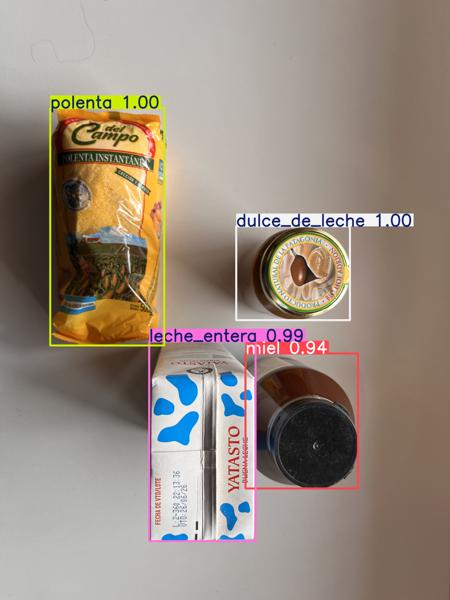


Imagen: IMG_3253.jpg

POC (individual):     0 detecciones
Multiproduct:         4 detecciones


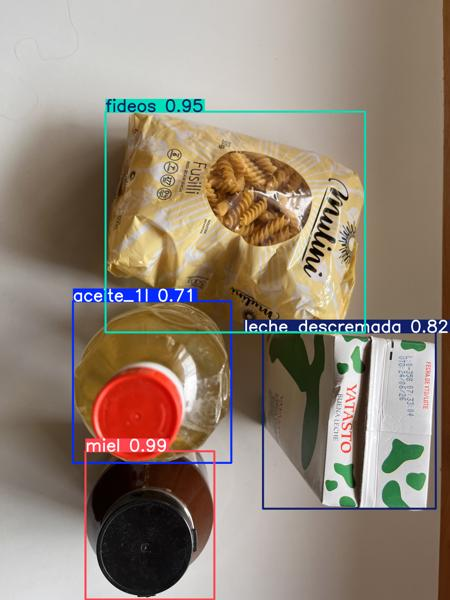


Imagen: IMG_3252.jpg

POC (individual):     1 detecciones
Multiproduct:         4 detecciones


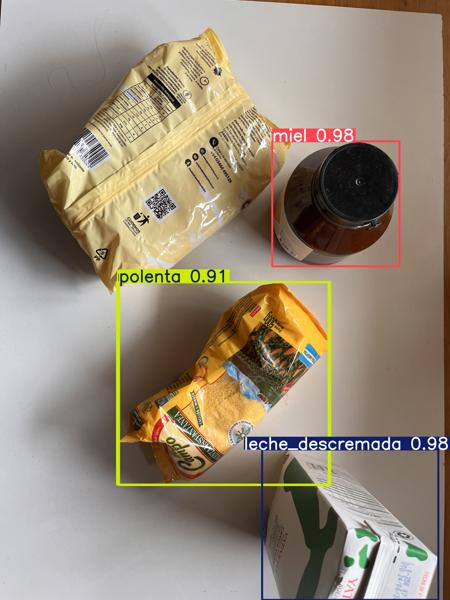

In [10]:
# Comparar en imágenes multi-producto
from IPython.display import Image, display
from PIL import Image as PILImage
import io

multi_product_dir = Path("../data/jpg/varios_productos")

if multi_product_dir.exists() and poc_model_path.exists():
    test_images = list(multi_product_dir.glob("*.jpg"))[:3]
    
    for img_path in test_images:
        print(f"\n{'='*60}")
        print(f"Imagen: {img_path.name}")
        print(f"{'='*60}")
        
        # POC model
        poc_results = poc_model.predict(source=str(img_path), conf=0.5, verbose=False)
        poc_detections = len(poc_results[0].boxes)
        
        # Multiproduct model
        multi_results = multiproduct_model.predict(source=str(img_path), conf=0.5, verbose=False)
        multi_detections = len(multi_results[0].boxes)
        
        print(f"\nPOC (individual):     {poc_detections} detecciones")
        print(f"Multiproduct:         {multi_detections} detecciones")
        
        # Mostrar resultado del modelo multiproduct
        img_with_boxes = multi_results[0].plot()
        pil_img = PILImage.fromarray(img_with_boxes[..., ::-1])
        pil_img.thumbnail((600, 600))
        buf = io.BytesIO()
        pil_img.save(buf, format='JPEG')
        buf.seek(0)
        display(Image(data=buf.read()))

## Guardar modelo final

In [11]:
import shutil

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Guardar como best_multiproduct.pt
dest_path = models_dir / "best_multiproduct.pt"
shutil.copy(best_model_path, dest_path)
print(f"Modelo guardado en: {dest_path}")

# También actualizar best.pt si el rendimiento es mejor
print("\nPara usar este modelo como principal:")
print(f"  cp {dest_path} {models_dir}/best.pt")

Modelo guardado en: ../models/best_multiproduct.pt

Para usar este modelo como principal:
  cp ../models/best_multiproduct.pt ../models/best.pt
